# Task 1: Web scraping to gain company insights

* Data Collection
  - scrape airline's reviews from Skytrax website.
* Analyze data
  - perform Exploratory Data Analysis.
  - perform word cloud and sentiment analysis to provide some insight into the content of the reviews.
* Present insights
  - summarise the findings within a single PowerPoint.



## Data Collection: Scraping data from Skytrax

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

In [ ]:
# scrap data from Skytrax

base_url = "https://www.airlinequality.com/airline-reviews/british-airways"
pages = 40
page_size = 100
reviews = []
date_published = []
country = []
overall_ratings = []
seat_type = []
seat_confort = []
staff_service = []
food_beverages = []
inflight_entertainment = []
value_for_money = []
recommended = []

for i in range(1, pages + 1):
  print(f"Scraping page {i}")
  url = f"{base_url}/page/{i}/?sortby=post_date%3ADesc&pagesize={page_size}"
  response = requests.get(url)
  content = response.content
  parsed_content = BeautifulSoup(content, 'html.parser')

  for review in parsed_content.find_all("article", {"itemprop": "review"}):

    reviews.append(review.find("div", {"class": "text_content"}).get_text())

    date_published.append(review.find("time", {"itemprop": "datePublished"})['datetime'])

    try:
      overall_ratings.append(review.find("div", class_="rating-10").span.text)
    except:
      overall_ratings.append(None)

    country.append(review.find("h3").span.next_sibling.text.strip(" ()"))

    table = review.find("table", {"class": "review-ratings"})
    stype = sconfort = staff = food = entertainment = value4money = recommend = None
    rows = table.find_all("tr")

    for row in rows:
      category_td = row.find("td", class_="review-rating-header")
      if category_td:
        category = category_td.text.strip()
        if category == "Seat Type":
          stype=(row.find("td", {"class": "review-value"} ).get_text().strip())

        if category == "Recommended":
          recommend=(row.find("td", {"class": "review-value"} ).get_text().strip())

        if category == "Seat Comfort":
          rating_td = row.find("td", {"class","review-rating-stars"})
          if rating_td.find("span").text.strip().upper() == 'N/A':
            sconfort=None
          else:
            sconfort = len(rating_td.find_all("span", {"class": "star fill"}))

        if category == "Cabin Staff Service":
          rating_td = row.find("td", {"class","review-rating-stars"})
          if rating_td.find("span").text.strip().upper() == 'N/A':
            staff=None
          else:
            staff = len(rating_td.find_all("span", {"class": "star fill"}))

        if category == "Food & Beverages":
          rating_td = row.find("td", {"class","review-rating-stars"})
          if rating_td.find("span").text.strip().upper() == 'N/A':
            food=None
          else:
            food = len(rating_td.find_all("span", {"class": "star fill"}))

        if category == "Inflight Entertainment":
          rating_td = row.find("td", {"class","review-rating-stars"})
          if rating_td.find("span").text.strip().upper() == 'N/A':
            entertainment=None
          else:
            entertainment = len(rating_td.find_all("span", {"class": "star fill"}))

        if category == "Value For Money":
          rating_td = row.find("td", {"class","review-rating-stars"})
          if rating_td.find("span").text.strip().upper() == 'N/A':
            value4money=None
          else:
            value4money = len(rating_td.find_all("span", {"class": "star fill"}))

    seat_type.append(stype)
    seat_confort.append(sconfort)
    staff_service.append(staff)
    food_beverages.append(food)
    inflight_entertainment.append(entertainment)
    value_for_money.append(value4money)
    recommended.append(recommend)

  print(f"   ---> {len(reviews)} total reviews")

Scraping page 1
   ---> 100 total reviews
Scraping page 2
   ---> 200 total reviews
Scraping page 3
   ---> 300 total reviews
Scraping page 4
   ---> 400 total reviews
Scraping page 5
   ---> 500 total reviews
Scraping page 6
   ---> 600 total reviews
Scraping page 7
   ---> 700 total reviews
Scraping page 8
   ---> 800 total reviews
Scraping page 9
   ---> 900 total reviews
Scraping page 10
   ---> 1000 total reviews
Scraping page 11
   ---> 1100 total reviews
Scraping page 12
   ---> 1200 total reviews
Scraping page 13
   ---> 1300 total reviews
Scraping page 14
   ---> 1400 total reviews
Scraping page 15
   ---> 1500 total reviews
Scraping page 16
   ---> 1600 total reviews
Scraping page 17
   ---> 1700 total reviews
Scraping page 18
   ---> 1800 total reviews
Scraping page 19
   ---> 1900 total reviews
Scraping page 20
   ---> 2000 total reviews
Scraping page 21
   ---> 2100 total reviews
Scraping page 22
   ---> 2200 total reviews
Scraping page 23
   ---> 2300 total reviews
Scrapi

In [ ]:
df = pd.DataFrame()
df['reviews'] = reviews
df['date_published'] = date_published
df['country'] = country
df['overall_rating'] = overall_ratings
df['seat_type'] = seat_type
df['seat_confort'] = seat_confort
df['staff_service'] = staff_service
df['food_beverages'] = food_beverages
df['inflight_entertainment'] = inflight_entertainment
df['value_for_money'] = value_for_money
df['recommended'] = recommended
df.head()

,reviews,date_published,country,overall_rating,seat_type,seat_confort,staff_service,food_beverages,inflight_entertainment,value_for_money,recommended
0,Not Verified | LHR T5 BA Gold Wing worked wel...,2025-04-03,United Kingdom,9,First Class,5.0,5.0,5.0,5.0,4.0,yes
1,Not Verified | Very good service on this rout...,2025-03-31,United Kingdom,10,Business Class,4.0,5.0,5.0,NaN,4.0,yes
2,✅ Trip Verified | Flight mainly let down by ...,2025-03-19,United Kingdom,7,Business Class,5.0,2.0,5.0,5.0,4.0,yes
3,✅ Trip Verified | Another awful experience b...,2025-03-16,United States,1,Business Class,1.0,1.0,NaN,NaN,1.0,no
4,"✅ Trip Verified | The service was rude, full...",2025-03-16,United States,3,Premium Economy,1.0,1.0,1.0,NaN,1.0,no


In [ ]:
# save data to BA_reviews.csv
df.to_csv("BA_reviews.csv")

## Exploratory Data Analysis

In [ ]:
import re
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# read data from BA_reviews.csv and check the data

df = pd.read_csv("BA_reviews.csv", index_col = 0)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3926 entries, 0 to 3925
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   reviews                 3926 non-null   object 
 1   date_published          3926 non-null   object 
 2   country                 3924 non-null   object 
 3   overall_rating          3921 non-null   float64
 4   seat_type               3924 non-null   object 
 5   seat_confort            3799 non-null   float64
 6   staff_service           3784 non-null   float64
 7   food_beverages          3486 non-null   float64
 8   inflight_entertainment  2671 non-null   float64
 9   value_for_money         3925 non-null   float64
 10  recommended             3926 non-null   object 
dtypes: float64(6), object(5)
memory usage: 368.1+ KB


In [ ]:
df.describe()

,overall_rating,seat_confort,staff_service,food_beverages,inflight_entertainment,value_for_money
count,3921.000000,3799.000000,3784.000000,3486.000000,2671.000000,3925.000000
mean,4.682224,2.860753,3.235201,2.710843,2.654811,2.663439
std,3.178373,1.366042,1.493193,1.438807,1.401141,1.470089
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,2.000000,2.000000,2.000000,1.000000,1.000000,1.000000
50%,4.000000,3.000000,3.000000,3.000000,3.000000,3.000000
75%,8.000000,4.000000,5.000000,4.000000,4.000000,4.000000
max,10.000000,5.000000,5.000000,5.000000,5.000000,5.000000


### convert the data type of datePublished to datetime

In [ ]:
df['date_published'] = pd.to_datetime(df['date_published'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3926 entries, 0 to 3925
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   reviews                 3926 non-null   object        
 1   date_published          3926 non-null   datetime64[ns]
 2   country                 3924 non-null   object        
 3   overall_rating          3921 non-null   float64       
 4   seat_type               3924 non-null   object        
 5   seat_confort            3799 non-null   float64       
 6   staff_service           3784 non-null   float64       
 7   food_beverages          3486 non-null   float64       
 8   inflight_entertainment  2671 non-null   float64       
 9   value_for_money         3925 non-null   float64       
 10  recommended             3926 non-null   object        
dtypes: datetime64[ns](1), float64(6), object(4)
memory usage: 368.1+ KB


### check missing values

In [ ]:
df.isnull().sum()

,0
reviews,0
date_published,0
country,2
overall_rating,5
seat_type,2
seat_confort,127
staff_service,142
food_beverages,440
inflight_entertainment,1255
value_for_money,1


### Handling missing value of 'seat type'

In [ ]:
# drop the rows where  value is missing
df = df.dropna(subset=['seat_type']).reset_index(drop=True)
df.shape

(3924, 11)

### Handling missing value of 'country'

In [ ]:
df = df.dropna(subset=['country']).reset_index(drop=True)
df.shape

(3922, 11)

### Handling missing value of 'value for money'

In [ ]:
# check the rows where 'value for money' is null
df[df['value_for_money'].isnull()]

,reviews,date_published,country,overall_rating,seat_type,seat_confort,staff_service,food_beverages,inflight_entertainment,value_for_money,recommended
3912,HKG-LHR in New Club World on Boeing 777-300 - ...,2012-08-29,United Kingdom,6.0,Business Class,4.0,3.0,3.0,4.0,NaN,yes


In [ ]:
# find rows with similar attributes to guide imputation for the missing value of 'value_for_money''
df[(df['overall_rating']==6.0) & (df['recommended']=='yes') & (df['seat_confort']==4.0) & (df['staff_service']==3.0) & (df['food_beverages']==3.0) & (df['inflight_entertainment']==4.0)]

,reviews,date_published,country,overall_rating,seat_type,seat_confort,staff_service,food_beverages,inflight_entertainment,value_for_money,recommended
3138,"I flew from Seoul to London, business class an...",2015-06-16,United Kingdom,6.0,Business Class,4.0,3.0,3.0,4.0,3.0,yes
3912,HKG-LHR in New Club World on Boeing 777-300 - ...,2012-08-29,United Kingdom,6.0,Business Class,4.0,3.0,3.0,4.0,NaN,yes


In [ ]:
# Fill missing value of 'value_for_money' based on similar record
df.loc[[3912],['value_for_money']] = 3.0
df.loc[[3912]]

,reviews,date_published,country,overall_rating,seat_type,seat_confort,staff_service,food_beverages,inflight_entertainment,value_for_money,recommended
3912,HKG-LHR in New Club World on Boeing 777-300 - ...,2012-08-29,United Kingdom,6.0,Business Class,4.0,3.0,3.0,4.0,3.0,yes


### Handling missing value of 'overall rating'

In [ ]:
# check the rows where 'overall rating' value is missing
df[df['overall_rating'].isnull()]

,reviews,date_published,country,overall_rating,seat_type,seat_confort,staff_service,food_beverages,inflight_entertainment,value_for_money,recommended
3351,Cabin crew polite unfortunately BA ran out of ...,2015-02-18,United Kingdom,NaN,Economy Class,3.0,5.0,1.0,1.0,2.0,no
3477,Phoenix to London - outbound a wonderful and e...,2014-12-10,United States,NaN,First Class,1.0,5.0,4.0,2.0,2.0,no
3499,On past experience I chose BA for our long hau...,2014-11-25,United Kingdom,NaN,Economy Class,3.0,3.0,2.0,1.0,3.0,no
3729,LHR-CPH-LHR Business Class. This is a joke. Sc...,2014-07-31,United Kingdom,NaN,Business Class,1.0,1.0,1.0,1.0,1.0,no
3763,I flew with British Airways with my mother fro...,2014-07-15,Italy,NaN,Economy Class,1.0,3.0,1.0,1.0,1.0,no


In [ ]:
# impute missing 'overall_rating' using the rounded mean within each ('seat_type', 'recommended', 'value_for_money') group
df['overall_rating'] = df.groupby(['recommended', 'value_for_money'])['overall_rating'].transform(
    lambda x: x.fillna(x.mean().round()))
df.iloc[[3351, 3477, 3499, 3729, 3763]]

,reviews,date_published,country,overall_rating,seat_type,seat_confort,staff_service,food_beverages,inflight_entertainment,value_for_money,recommended
3351,Cabin crew polite unfortunately BA ran out of ...,2015-02-18,United Kingdom,3.0,Economy Class,3.0,5.0,1.0,1.0,2.0,no
3477,Phoenix to London - outbound a wonderful and e...,2014-12-10,United States,3.0,First Class,1.0,5.0,4.0,2.0,2.0,no
3499,On past experience I chose BA for our long hau...,2014-11-25,United Kingdom,4.0,Economy Class,3.0,3.0,2.0,1.0,3.0,no
3729,LHR-CPH-LHR Business Class. This is a joke. Sc...,2014-07-31,United Kingdom,2.0,Business Class,1.0,1.0,1.0,1.0,1.0,no
3763,I flew with British Airways with my mother fro...,2014-07-15,Italy,2.0,Economy Class,1.0,3.0,1.0,1.0,1.0,no


### Handling missing value of seat_confort, staff_service, food_beverages, and inflight_entertainment.

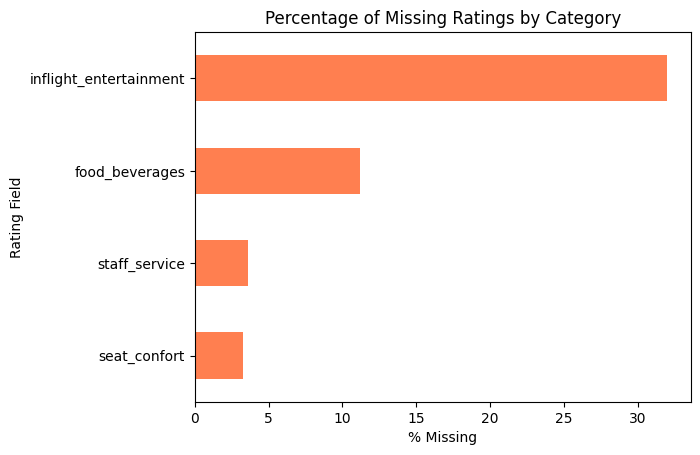

In [ ]:
# How much data is missing per category?

missing_percent = df[['seat_confort', 'staff_service', 'food_beverages','inflight_entertainment']].isnull().mean()*100

missing_percent.sort_values().plot(kind='barh', color='coral')

plt.title('Percentage of Missing Ratings by Category')
plt.xlabel('% Missing')
plt.ylabel('Rating Field')
plt.show()

**Missing values in seat_confort, staff_service, food_beverages, and inflight_entertainment are treated as *‘not rated’*.**

### Data Preprocessing for 'Reviews'

In [ ]:
import nltk
from nltk.tokenize import word_tokenize
from nltk import pos_tag
from nltk.corpus import stopwords
from nltk.corpus import wordnet
from nltk.stem import WordNetLemmatizer

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


True

In [ ]:
# Remove the parts before |
df['cleaned_reviews'] = df['reviews'].apply(lambda x: re.sub(r'^(Not Verified \| |✅ Trip Verified \| )', '', x))

# Remove special characters, and punctuations
df['cleaned_reviews'] = df['cleaned_reviews'].str.lower().apply(lambda x: re.sub('[^\w\s]','',x))

# Tokenize
df['cleaned_reviews'] = df['cleaned_reviews'].apply(lambda x: word_tokenize(x))

# Remove stopwords
stop_words = set(stopwords.words('english'))
df['cleaned_reviews'] = df['cleaned_reviews'].apply(lambda x: [word for word in x if word not in stop_words])

# remove words that have less than 2 letters
df['cleaned_reviews'] = df['cleaned_reviews'].apply(lambda x: [word for word in x if len(word) > 2])

df[['reviews','cleaned_reviews']].head()

,reviews,cleaned_reviews
0,Not Verified | LHR T5 BA Gold Wing worked wel...,"[lhr, gold, wing, worked, well, pleasant, chec..."
1,Not Verified | Very good service on this rout...,"[good, service, route, ba2710, 30th, march, ca..."
2,✅ Trip Verified | Flight mainly let down by ...,"[flight, mainly, let, disagreeable, flight, at..."
3,✅ Trip Verified | Another awful experience b...,"[another, awful, experience, british, airways,..."
4,"✅ Trip Verified | The service was rude, full...","[service, rude, full, attitude, food, poorly, ..."


In [ ]:
#POS tagged
df['tagged_reviews'] = df['cleaned_reviews'].apply(lambda x: pos_tag(x))
df[['reviews','cleaned_reviews','tagged_reviews']].head()

,reviews,cleaned_reviews,tagged_reviews
0,Not Verified | LHR T5 BA Gold Wing worked wel...,"[lhr, gold, wing, worked, well, pleasant, chec...","[(lhr, JJ), (gold, NN), (wing, NN), (worked, V..."
1,Not Verified | Very good service on this rout...,"[good, service, route, ba2710, 30th, march, ca...","[(good, JJ), (service, NN), (route, NN), (ba27..."
2,✅ Trip Verified | Flight mainly let down by ...,"[flight, mainly, let, disagreeable, flight, at...","[(flight, NN), (mainly, RB), (let, RBR), (disa..."
3,✅ Trip Verified | Another awful experience b...,"[another, awful, experience, british, airways,...","[(another, DT), (awful, JJ), (experience, NN),..."
4,"✅ Trip Verified | The service was rude, full...","[service, rude, full, attitude, food, poorly, ...","[(service, NN), (rude, VBP), (full, JJ), (atti..."


In [ ]:
# Lemmatization
lemmatizer = WordNetLemmatizer()
pos_dict = {'J':wordnet.ADJ, 'V':wordnet.VERB, 'N':wordnet.NOUN, 'R':wordnet.ADV}
df['lemmatized_reviews'] = df['tagged_reviews'].apply(lambda x: ' '.join([lemmatizer.lemmatize(w, pos_dict.get(tag[0], wordnet.NOUN)) for w,tag in x])) # If tag[0] is not in pos_dict, use NOUN as the default POS tag

df[['reviews','cleaned_reviews', 'tagged_reviews', 'lemmatized_reviews']].head(3)

,reviews,cleaned_reviews,tagged_reviews,lemmatized_reviews
0,Not Verified | LHR T5 BA Gold Wing worked wel...,"[lhr, gold, wing, worked, well, pleasant, chec...","[(lhr, JJ), (gold, NN), (wing, NN), (worked, V...",lhr gold wing work well pleasant check fast se...
1,Not Verified | Very good service on this rout...,"[good, service, route, ba2710, 30th, march, ca...","[(good, JJ), (service, NN), (route, NN), (ba27...",good service route ba2710 30th march cabin cre...
2,✅ Trip Verified | Flight mainly let down by ...,"[flight, mainly, let, disagreeable, flight, at...","[(flight, NN), (mainly, RB), (let, RBR), (disa...",flight mainly let disagreeable flight attendan...


In [ ]:
df.head(3)

,reviews,date_published,country,overall_rating,seat_type,seat_confort,staff_service,food_beverages,inflight_entertainment,value_for_money,recommended,cleaned_reviews,tagged_reviews,lemmatized_reviews
0,Not Verified | LHR T5 BA Gold Wing worked wel...,2025-04-03,United Kingdom,9.0,First Class,5.0,5.0,5.0,5.0,4.0,yes,"[lhr, gold, wing, worked, well, pleasant, chec...","[(lhr, JJ), (gold, NN), (wing, NN), (worked, V...",lhr gold wing work well pleasant check fast se...
1,Not Verified | Very good service on this rout...,2025-03-31,United Kingdom,10.0,Business Class,4.0,5.0,5.0,NaN,4.0,yes,"[good, service, route, ba2710, 30th, march, ca...","[(good, JJ), (service, NN), (route, NN), (ba27...",good service route ba2710 30th march cabin cre...
2,✅ Trip Verified | Flight mainly let down by ...,2025-03-19,United Kingdom,7.0,Business Class,5.0,2.0,5.0,5.0,4.0,yes,"[flight, mainly, let, disagreeable, flight, at...","[(flight, NN), (mainly, RB), (let, RBR), (disa...",flight mainly let disagreeable flight attendan...


In [ ]:
df.to_csv("cleaned_BA_reviews.csv")

### **Average overall rating given for British Airways**

In [ ]:
print(f'{df.overall_rating.mean():.4f}')

4.6813


The mean overall rating across all records is approximately 4.6813.

### **Distribution of Overall Rating**

<ipython-input-24-942cc146ee49>:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='overall_rating', palette='Set2')


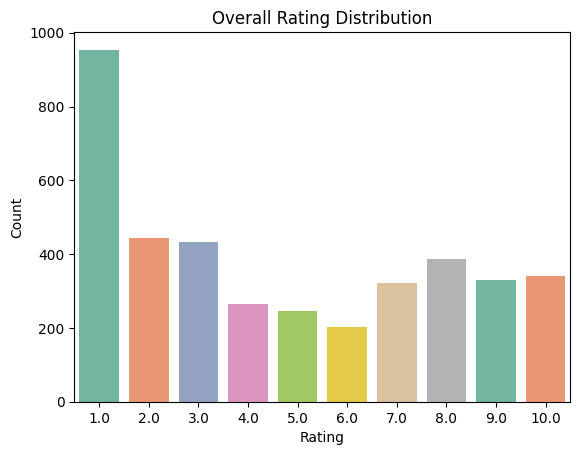

In [ ]:
sns.countplot(data=df, x='overall_rating', palette='Set2')
plt.title('Overall Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

Higher ratings like 10.0 and 9.0 are less frequent, showing that the ratings are skewed toward the lower end.

### Average Overall Rating by Seat Type

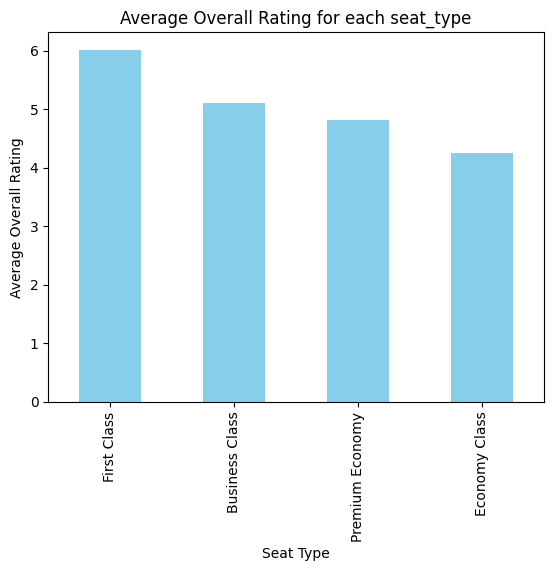

In [ ]:
seat_type_rating = df.groupby('seat_type')['overall_rating'].mean().sort_values(ascending=False)
seat_type_rating.plot(kind='bar', color='skyblue')
plt.title('Average Overall Rating for each seat_type')
plt.xlabel('Seat Type')
plt.ylabel('Average Overall Rating')
plt.show()

Passengers in higher-end seats tend to rate their experience more favorably and there is a more negative perception among economy passengers.

### How Often Do Passengers Recommend the Flight?

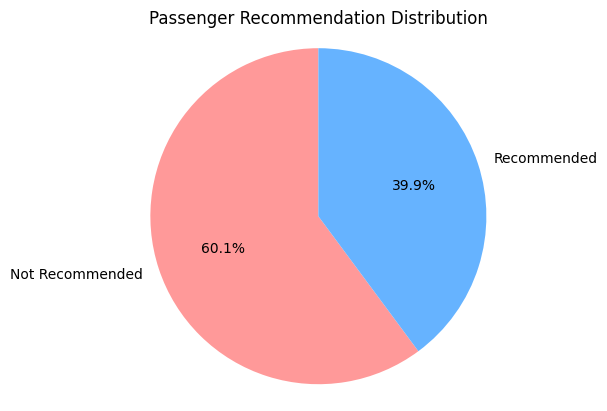

In [ ]:
recommend_counts = df['recommended'].value_counts().sort_index()

labels = ['Not Recommended', 'Recommended']
colors = ['#FF9999', '#66B3FF']

plt.pie(recommend_counts, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors)
plt.title('Passenger Recommendation Distribution')
plt.axis('equal')
plt.show()

Most of the passengers did not recommended the service.

### Count of Recommended vs Not Recommended for each seat_type

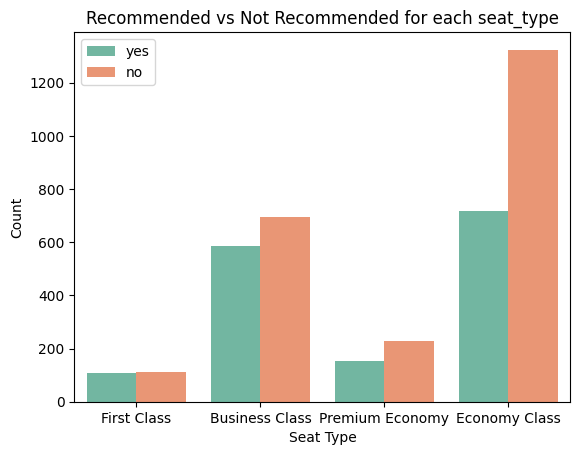

In [ ]:
sns.countplot(data=df, x='seat_type', hue='recommended', palette='Set2')
plt.title('Recommended vs Not Recommended for each seat_type')
plt.xlabel('Seat Type')
plt.ylabel('Count')
plt.legend()
plt.show()

First Class and Business Class have the higher recommendation rate.

### Distribution of Flight Recommendations Across Overall Ratings

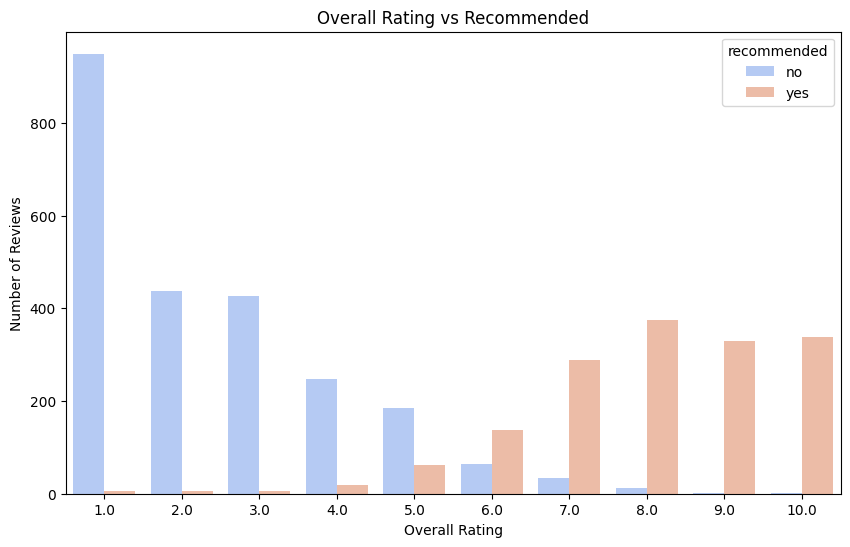

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='overall_rating', hue='recommended', palette='coolwarm')
plt.title('Overall Rating vs Recommended')
plt.xlabel('Overall Rating')
plt.ylabel('Number of Reviews')
plt.show()


In [ ]:
pd.crosstab(df['overall_rating'], df['recommended'])

recommended,no,yes
overall_rating,,
1.0,949,5
2.0,438,5
3.0,427,6
4.0,247,18
5.0,184,62
6.0,65,137
7.0,34,289
8.0,12,374
9.0,1,329


Although most people who give higher overall ratings recommend the flight, there are still some cases where passengers rate the airline highly but choose not to recommend it.

### Which aspects of the flight get the highest and lowest stars?

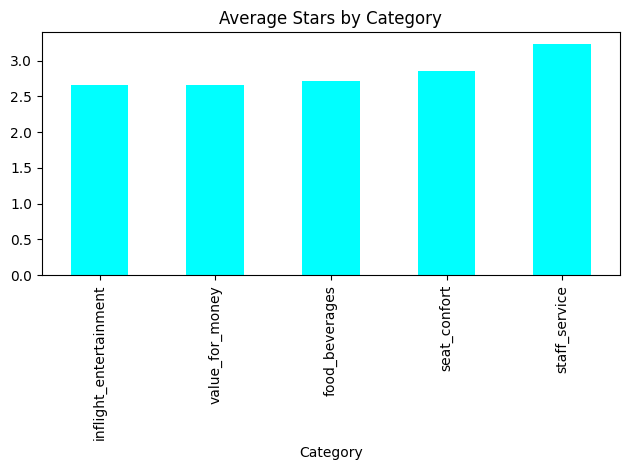

In [ ]:
star_categories = ['seat_confort', 'staff_service', 'food_beverages', 'inflight_entertainment', 'value_for_money']
avg_ratings = df[star_categories].mean().sort_values()

avg_ratings.plot(kind='bar', color='cyan')
plt.title('Average Stars by Category')
plt.xlabel('Category')
plt.tight_layout()
plt.show()


Staff service received the highest rating, reflecting high levels of customer satisfaction in this area.

### Which seat type offers the best experience overall?

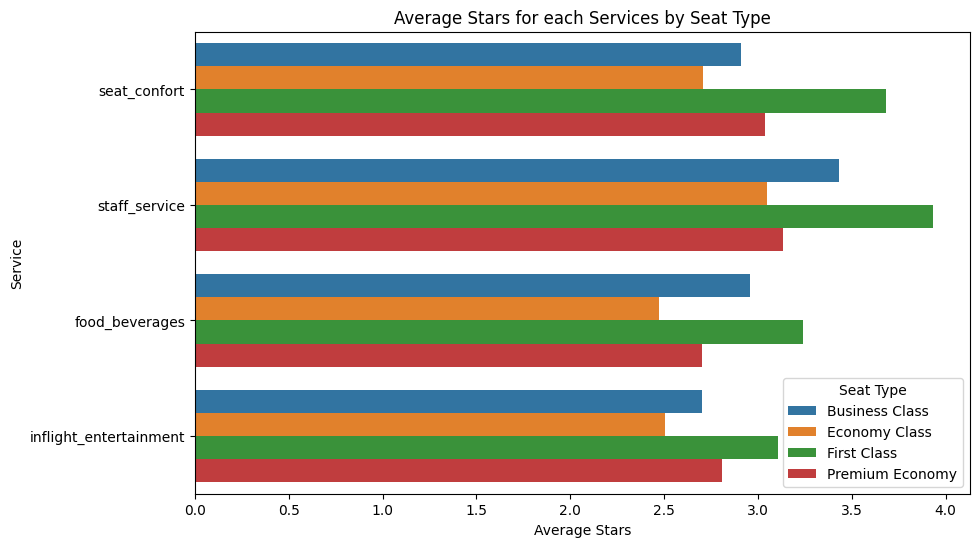

In [ ]:
star_categories = ['seat_confort', 'staff_service', 'food_beverages', 'inflight_entertainment']
seat_type_avg = df.groupby('seat_type')[star_categories].mean().reset_index()
seat_type_avg = seat_type_avg.melt(id_vars='seat_type', var_name='Category', value_name='Average Rating')

plt.figure(figsize=(10, 6))
sns.barplot(data=seat_type_avg, x='Average Rating', y='Category', hue='seat_type')
plt.title('Average Stars for each Services by Seat Type')
plt.xlabel('Average Stars')
plt.ylabel('Service')
plt.legend(title='Seat Type')
plt.show()


First Class passengers have the highest satisfaction ratings across most categories, while Economy Class passengers are the least satisfied.

### Is It Worth the Money?

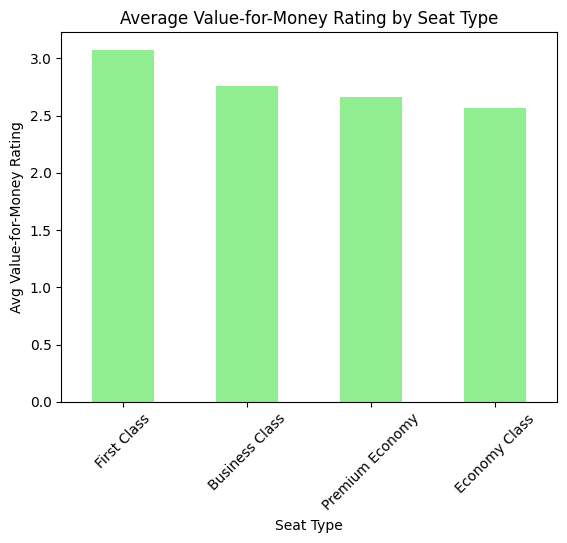

In [ ]:
seat_type_value = df.groupby('seat_type')['value_for_money'].mean().sort_values(ascending=False)
seat_type_value.plot(kind='bar', color='lightgreen')
plt.title('Average Value-for-Money Rating by Seat Type')
plt.xlabel('Seat Type')
plt.ylabel('Avg Value-for-Money Rating')
plt.xticks(rotation=45)
plt.show()

Passengers in higher-priced seats feel they are getting more value.

###  Average rating by seat type per year

Not much can be inferred from the plot as the dates we have are the when the customers posted their reviews which does not take into account the actual flight date.

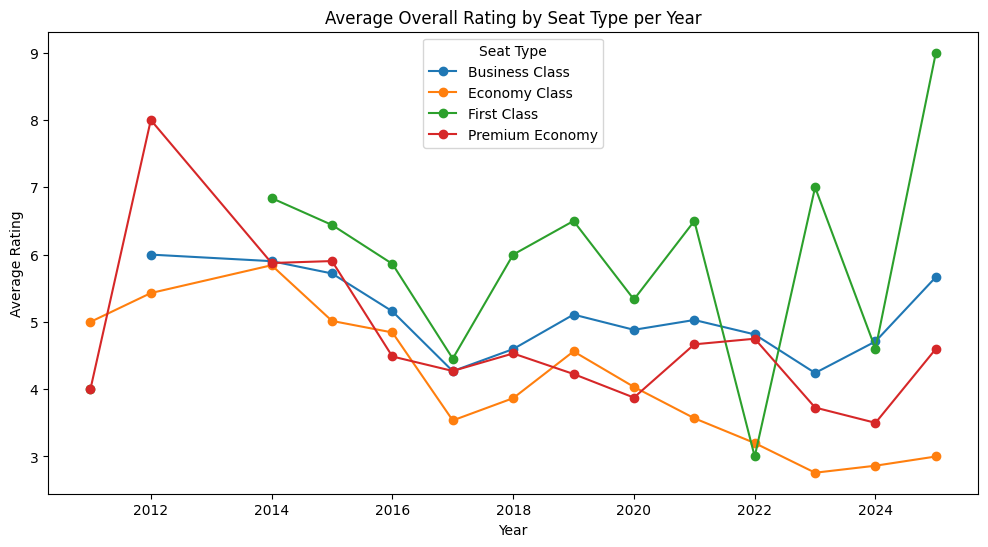

In [ ]:
df['published_year'] = df['date_published'].dt.year
grouped_rating = df.groupby(['published_year', 'seat_type'])['overall_rating'].mean().unstack()
grouped_rating.plot(kind='line', marker='o', figsize=(12, 6))
plt.title('Average Overall Rating by Seat Type per Year')
plt.xlabel('Year')
plt.ylabel('Average Rating')
plt.legend(title='Seat Type')
plt.show()

### Countries

In [ ]:
df['country'].unique().shape

(74,)

In [ ]:
sorted(df['country'].unique())

['Argentina',
 'Australia',
 'Austria',
 'Bahrain',
 'Barbados',
 'Belgium',
 'Bermuda',
 'Botswana',
 'Brazil',
 'Bulgaria',
 'Canada',
 'Cayman Islands',
 'Chile',
 'China',
 'Costa Rica',
 'Cyprus',
 'Czech Republic',
 'Denmark',
 'Dominican Republic',
 'Ecuador',
 'Egypt',
 'Finland',
 'France',
 'Germany',
 'Ghana',
 'Greece',
 'Hong Kong',
 'Hungary',
 'Iceland',
 'India',
 'Indonesia',
 'Ireland',
 'Israel',
 'Italy',
 'Japan',
 'Jordan',
 'Kuwait',
 'Laos',
 'Lebanon',
 'Luxembourg',
 'Malaysia',
 'Mexico',
 'Morocco',
 'Netherlands',
 'New Zealand',
 'Nigeria',
 'Norway',
 'Oman',
 'Panama',
 'Philippines',
 'Poland',
 'Portugal',
 'Qatar',
 'Romania',
 'Russian Federation',
 'Saint Kitts and Nevis',
 'Saudi Arabia',
 'Senegal',
 'Singapore',
 'Slovakia',
 'South Africa',
 'South Korea',
 'Spain',
 'Sweden',
 'Switzerland',
 'Taiwan',
 'Thailand',
 'Trinidad & Tobago',
 'Turkey',
 'Ukraine',
 'United Arab Emirates',
 'United Kingdom',
 'United States',
 'Vietnam']

### Countries with the Most Traveller Reviews

In [ ]:
df['country'].value_counts().head()

,count
country,
United Kingdom,2449
United States,455
Australia,165
Canada,125
Germany,68


### Top countries by average overall satisfaction

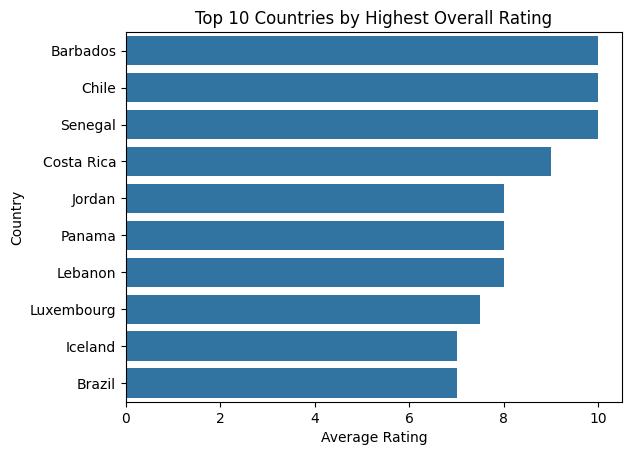

In [ ]:
country_rating = df.groupby('country')['overall_rating'].mean().sort_values(ascending=False).reset_index()
top10 = country_rating.head(10)

sns.barplot(data=top10, x='overall_rating', y='country')
plt.title('Top 10 Countries by Highest Overall Rating')
plt.xlabel('Average Rating')
plt.ylabel('Country')
plt.show()

Countries like Barbados, Chile, and Senegal have an average overall rating of 10.0, indicating a very high level of satisfaction in these regions.

### Countries with the Lowest Average Food & Beverages Ratings

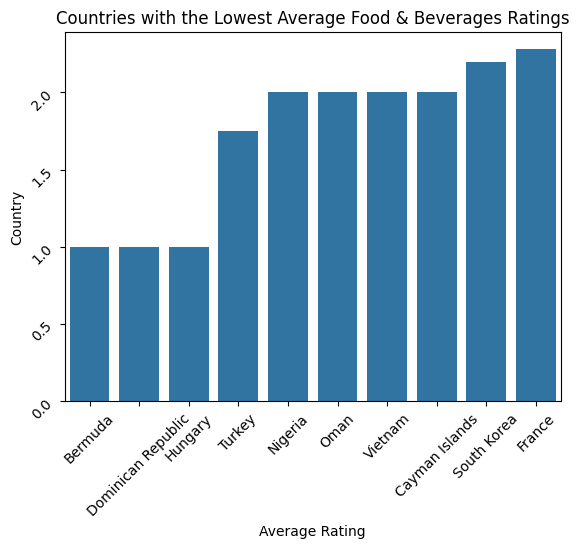

In [ ]:
country_food_rating = df.groupby('country')['food_beverages'].mean().sort_values(ascending=True).reset_index()
least10 = country_food_rating.dropna(subset=['food_beverages']).head(10)

sns.barplot(data=least10, y='food_beverages', x='country')
plt.title('Countries with the Lowest Average Food & Beverages Ratings')
plt.xlabel('Average Rating')
plt.ylabel('Country')
plt.tick_params(rotation=45)
plt.show()

 Countries like Bermuda, Hungary and Dominican Republic doesn't like the food & beverages of the airline.

### Passenger Experience in Top-Reviewing Countries: United Kingdom vs United States

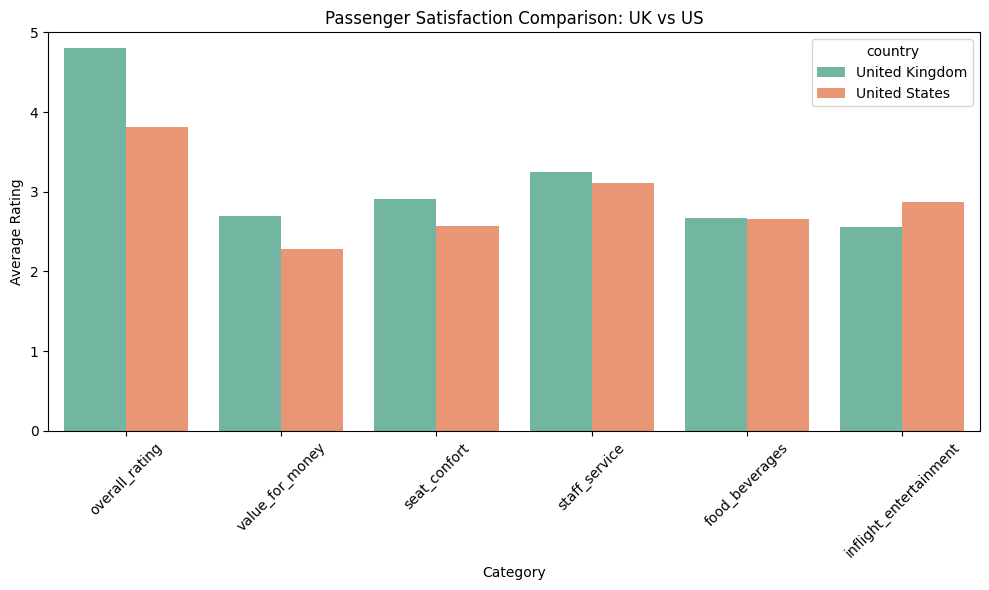

In [ ]:
uk_us = df[df['country'].isin(['United Kingdom', 'United States'])]

cols = ['overall_rating', 'value_for_money', 'seat_confort', 'staff_service', 'food_beverages', 'inflight_entertainment']

uk_us_avg = uk_us.groupby('country')[cols].mean().reset_index()

uk_us_melt = uk_us_avg.melt(id_vars='country', var_name='Category', value_name='Average Rating')

plt.figure(figsize=(10, 6))
sns.barplot(data=uk_us_melt, x='Category', y='Average Rating', hue='country', palette='Set2')
plt.title('Passenger Satisfaction Comparison: UK vs US')
plt.ylim(0, 5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


The United Kingdom also has slightly better ratings in categories such as seat comfort, and staff service,  while the United States performs better in inflight entertainment.

## Word Cloud

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud

In [ ]:
# read data from BA_reviews.csv
df = pd.read_csv("cleaned_BA_reviews.csv", index_col = 0)
df.head()

,reviews,date_published,country,overall_rating,seat_type,seat_confort,staff_service,food_beverages,inflight_entertainment,value_for_money,recommended,cleaned_reviews,tagged_reviews,lemmatized_reviews
0,Not Verified | LHR T5 BA Gold Wing worked wel...,2025-04-03,United Kingdom,9.0,First Class,5.0,5.0,5.0,5.0,4.0,yes,"['lhr', 'gold', 'wing', 'worked', 'well', 'ple...","[('lhr', 'JJ'), ('gold', 'NN'), ('wing', 'NN')...",lhr gold wing work well pleasant check fast se...
1,Not Verified | Very good service on this rout...,2025-03-31,United Kingdom,10.0,Business Class,4.0,5.0,5.0,NaN,4.0,yes,"['good', 'service', 'route', 'ba2710', '30th',...","[('good', 'JJ'), ('service', 'NN'), ('route', ...",good service route ba2710 30th march cabin cre...
2,✅ Trip Verified | Flight mainly let down by ...,2025-03-19,United Kingdom,7.0,Business Class,5.0,2.0,5.0,5.0,4.0,yes,"['flight', 'mainly', 'let', 'disagreeable', 'f...","[('flight', 'NN'), ('mainly', 'RB'), ('let', '...",flight mainly let disagreeable flight attendan...
3,✅ Trip Verified | Another awful experience b...,2025-03-16,United States,1.0,Business Class,1.0,1.0,NaN,NaN,1.0,no,"['another', 'awful', 'experience', 'british', ...","[('another', 'DT'), ('awful', 'JJ'), ('experie...",another awful experience british airway flight...
4,"✅ Trip Verified | The service was rude, full...",2025-03-16,United States,3.0,Premium Economy,1.0,1.0,1.0,NaN,1.0,no,"['service', 'rude', 'full', 'attitude', 'food'...","[('service', 'NN'), ('rude', 'VBP'), ('full', ...",service rude full attitude food poorly service...


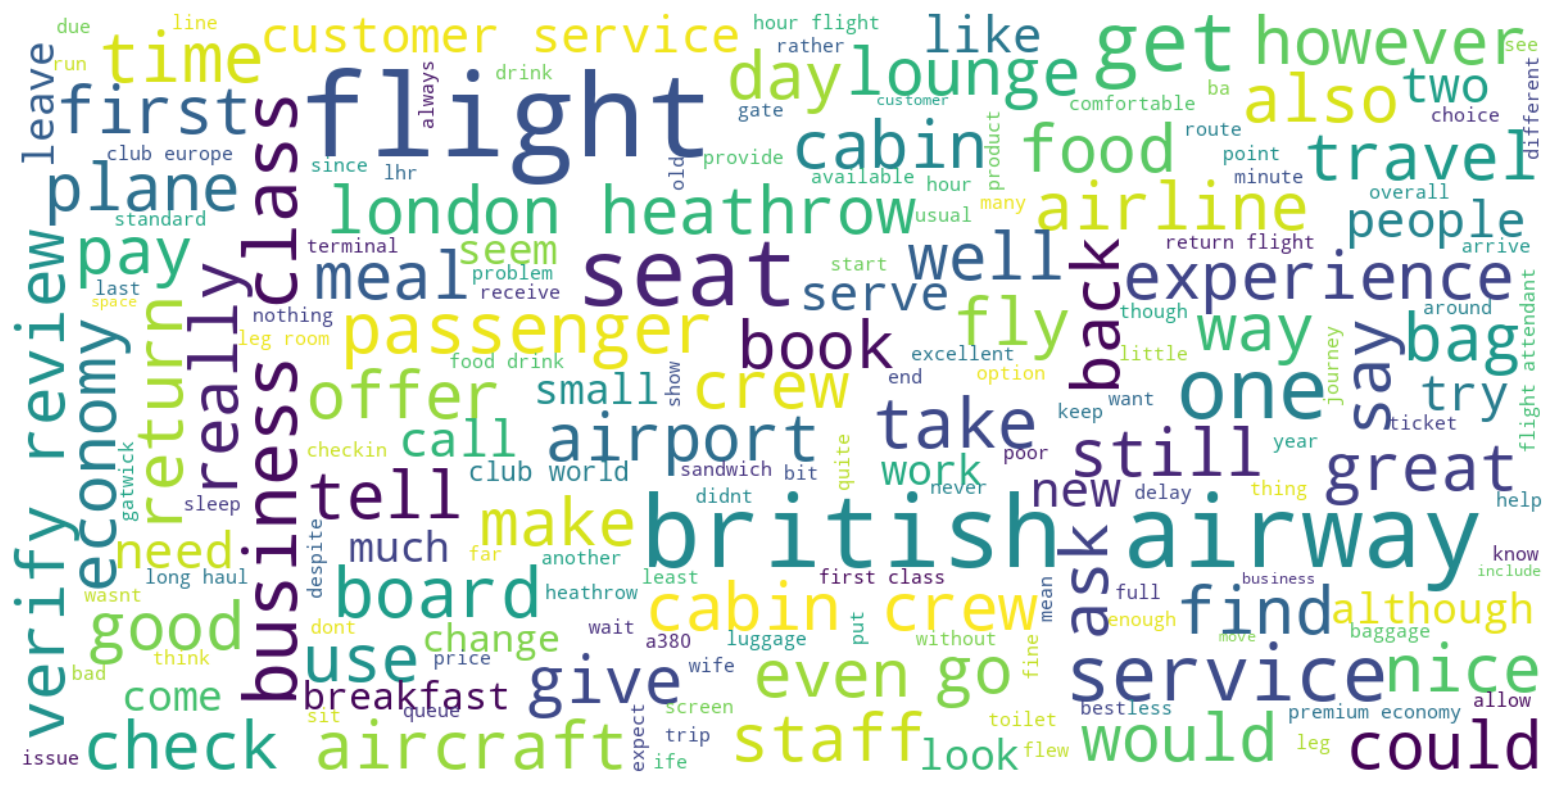

In [ ]:
stop_words = set(stopwords.words('english'))

wordcloud = WordCloud(
        background_color='white',
        stopwords=stop_words,
        max_words=200,
        max_font_size=30,
        scale=3,
        random_state=1)

lemmatized_reviews = ' '.join(df['lemmatized_reviews'])
wordcloud=wordcloud.generate(lemmatized_reviews)

plt.figure(figsize=(20, 10))
plt.axis('off')
plt.imshow(wordcloud, interpolation='bilinear')
plt.show()


Words such as 'brithish airway', and similar terms do not contribute meaningful information, so they will be added to the stopwords list.

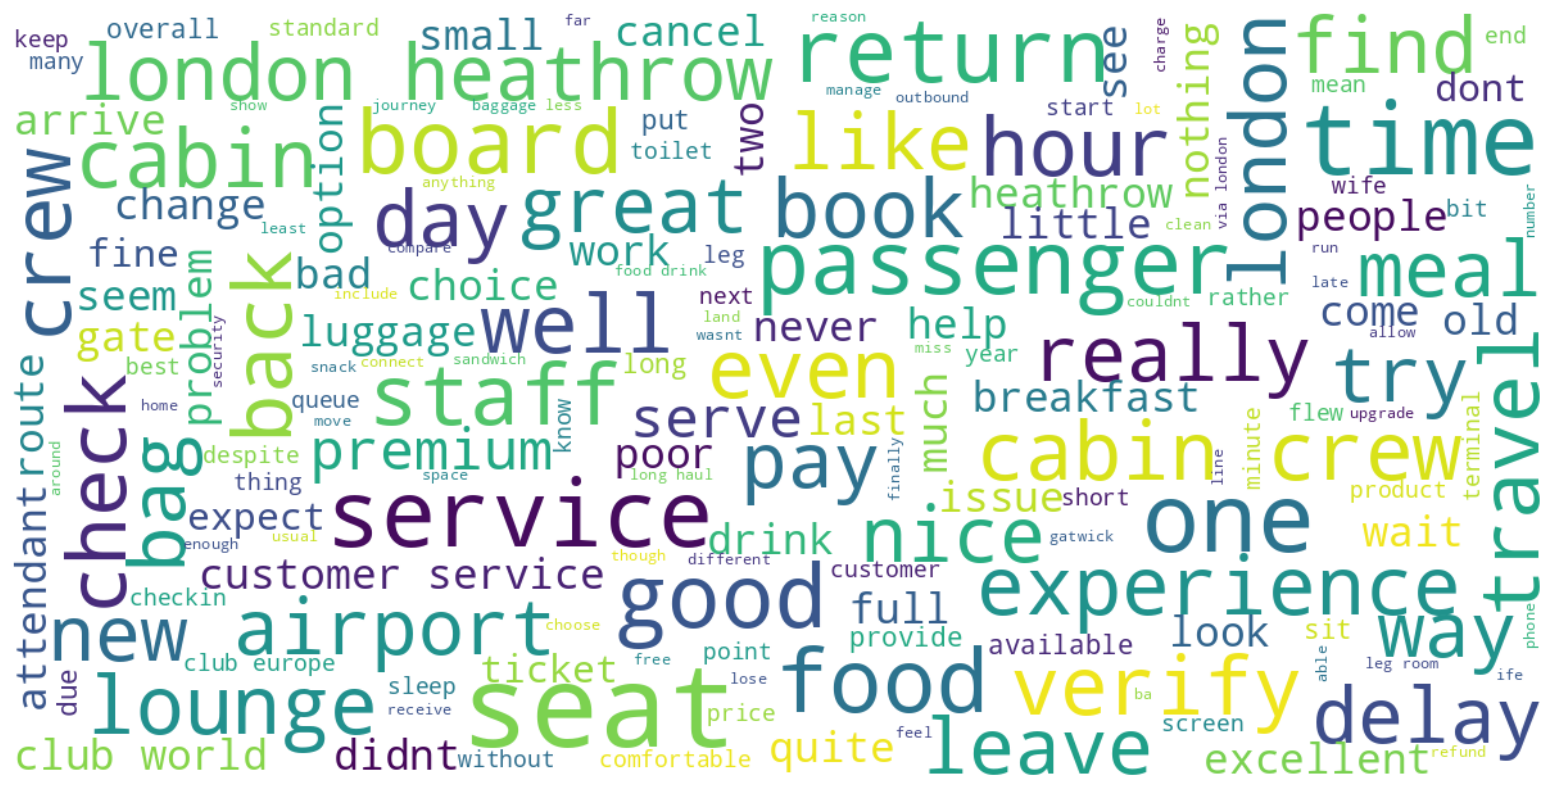

In [ ]:
stop_words = set(stopwords.words('english'))
stop_words.update(['british','airway', 'airline', 'aircraft', 'airplane', 'plane', 'flight','review',' really', 'lhr', 'a380', 'trip', 'although', 'however', 'another', 'go', 'fly','always','still', 'since','would','could', 'want', 'also', 'ask', 'say', 'call', 'tell', 'take', 'get', 'give', 'think', 'need', 'offer', 'make', 'use', 'business', 'class', 'first', 'economy'])

wordcloud = WordCloud(
        background_color='white',
        stopwords=stop_words,
        max_words=200,
        max_font_size=30,
        scale=3,
        random_state=1)

lemmatized_reviews = ' '.join(df['lemmatized_reviews'])
wordcloud=wordcloud.generate(lemmatized_reviews)

plt.figure(figsize=(20, 10))
plt.axis('off')
plt.imshow(wordcloud, interpolation='bilinear')
plt.show()

## Sentiment Analysis

In [ ]:
import pandas as pd
# show the full row content
pd.set_option('max_colwidth', None)

df = pd.read_csv('cleaned_BA_reviews.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3922 entries, 0 to 3921
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Unnamed: 0              3922 non-null   int64  
 1   reviews                 3922 non-null   object 
 2   date_published          3922 non-null   object 
 3   country                 3922 non-null   object 
 4   overall_rating          3922 non-null   float64
 5   seat_type               3922 non-null   object 
 6   seat_confort            3795 non-null   float64
 7   staff_service           3780 non-null   float64
 8   food_beverages          3482 non-null   float64
 9   inflight_entertainment  2667 non-null   float64
 10  value_for_money         3922 non-null   float64
 11  recommended             3922 non-null   object 
 12  cleaned_reviews         3922 non-null   object 
 13  tagged_reviews          3922 non-null   object 
 14  lemmatized_reviews      3922 non-null   

In [ ]:
frequent_words = ['british','airway', 'airline', 'aircraft', 'airplane', 'plane', 'flight','review',' really', 'lhr', 'a380', 'trip', 'although', 'however', 'another', 'go', 'fly','always','still', 'since','would','could', 'want', 'also', 'ask', 'say', 'call', 'tell', 'take', 'get', 'give', 'think', 'need', 'offer', 'make', 'use']
def remove_frequent_words(text):
  result = ' '.join([word for word in text.split() if word not in frequent_words])

  return result

df['final_reviews'] = df.lemmatized_reviews.apply(remove_frequent_words)

### Sentiment Analysis with TextBlob

In [ ]:
from textblob import TextBlob
from textblob.sentiments import NaiveBayesAnalyzer

def get_sentiment_textblob(text):
    sentiment = TextBlob(text).sentiment.polarity
    if sentiment > 0.1:
      return 'positive'
    elif sentiment < 0:
      return 'negative'
    else:
      return 'neutral'

df['sentiment_textblob'] = df['final_reviews'].apply(lambda x: get_sentiment_textblob(x))
df['sentiment_textblob'].value_counts()

,count
sentiment_textblob,
positive,1775
negative,1224
neutral,923


In [ ]:
pd.crosstab(df['recommended'],df['sentiment_textblob'], normalize='index') * 100

sentiment_textblob,negative,neutral,positive
recommended,,,
no,48.622298,30.224671,21.153031
yes,4.926424,13.435701,81.637876


In [ ]:
pd.crosstab(df['overall_rating'], df['sentiment_textblob'], normalize='index') * 100

sentiment_textblob,negative,neutral,positive
overall_rating,,,
1.0,60.167715,26.939203,12.893082
2.0,48.081264,32.054176,19.864560
3.0,45.496536,29.561201,24.942263
4.0,39.245283,31.320755,29.433962
5.0,21.544715,36.991870,41.463415
6.0,18.811881,29.207921,51.980198
7.0,8.049536,20.123839,71.826625
8.0,2.331606,13.989637,83.678756
9.0,1.515152,7.575758,90.909091


In [ ]:
df[df['sentiment_textblob'] == 'positive']['reviews']

,reviews
0,"Not Verified | LHR T5 BA Gold Wing worked well. Pleasant check in and very fast security screening. Concorde room service attentive. C gate boarding OK but nothing special for First Passengers. Latest BA version of first with only 8 suites with privacy doors. Comfortable seat with plenty of stowage. Good screen and good choice of IFE. Amenity kit good quality and bedding, pillows cushions and blankets all good. Excellent menu and food very well presented. Cabin crew could not have been more attentive and helpful without being obtrusive. On time departure and early arrival. Bags delivered relatively swiftly and priority tagged bags were first off. All in all one of the best BA First flights I’ve had in many years. Whilst not touching the Middle Eastern carriers BA First on this showing is easily the best way to cross the Atlantic."
2,"✅ Trip Verified | Flight mainly let down by a disagreeable flight attendant. No queue to check in at Cape Town - good. However checkin agent was unfamiliar with BA size and weight rules for sports bags so had to wait 10 minutes while phone calls were made -- annoying. Lounge was good. Gate service was excellent with organised queues. Seat was good (the new upgraded Club Suite). The zip broke off the amenity kit so it was unusable -- BA cutting corners too much here. Offered a cocktail service which came promptly and the drink was excellent. But no nuts! So I went off to the galley to ask for some nuts or a snack to go with it. I spoke to a male flight attendant who looked at me with utter distaste that I had the temerity to ask for nuts. The he said ""where have you come from?"". What a bizarre question. I said ""seat 8E"" to which he responded with a flick of his hand - ""go ask her, she's serving you."" I was stunned - I have not been treated that way in even the cheapest restaurants, let alone business class on a premium airline. The gentlemen concerned has no place in service or hospitality and should find a different line of work. Anyway, the food was good. The IFE worked fine. WiFi wasn't working. I managed 6.5 hours sleep and we got off the plane promptly despite being at a remote stand, requiring a bus. The luggage took quite a while to arrive. Overall 7/10. Would be 9/10 but for the rude staff member."
6,"✅ Trip Verified | This time British Airways managed to get everything right. The price of the tickets was reasonable and the timing was perfect. Boarding was smooth and the seats were comfortable – easy reline to enable dozing and sufficient pitch to get in and out. The table was firm enough to allow the use of a small laptop and mouse. A pre-flight soft drink or Prosecco was offered and both the food and drink were more than sufficient. The best part was the cabin crew – two in PE and they were both extremely efficient, pleasant and witty. There was a good selection of movies and both the screen and the headset worked perfectly."
7,"✅ Trip Verified | The seats were excellent, with a feel of much more room than the official seat pitch (I am 6ft 1in). We could sleep for a couple of hours (daytime flight), with the blinds down as they should be (no point booking a window seat in my view). I focus on seat quality much more than smiley faces and food (the food was middling, and the second meal, before landing, was distinctly sub-par)."
11,"✅ Trip Verified | First the good news, the club suites are such a huge improvement over the old business seats I hope I never see one again. The not so good news I’m afraid to say was the flight itself. The food has really gone downhill since my last flight, presumably this is a cost cutting measure. If other airlines can offer a really decent quality meal why can’t an airline of BA’s stature? I’ve always thought that a good crew can make up for all the shortcomings but not this time. The crew member looking after me could not have been more bored and was obviously just going through the motions. They couldn’t even be bothered to say cheerio, a

In [ ]:
df[df['sentiment_textblob'] == 'negative']['reviews']

,reviews
1,"Not Verified | Very good service on this route BA2710 30th March. Cabin crew worked hard, particularly Ivka (?) who was on the go throughout the flight. Everything you would expect of BA (and as it used to be!) Shame the same cannot be said on our recent flight back from Singapore, in Business Class on 11th Feb BA12. Miserable, unhappy and tetchy crew. Too lazy to do anything except sleep! Perhaps BA need to promote some of their short-haul performers, and let the others go."
3,✅ Trip Verified | Another awful experience by British Airways. This flight was delayed nearly 1 hour. British Airways charges an extortionate amount for their tickets but the service is bad for me.
4,"✅ Trip Verified | The service was rude, full of attitude to me, the food is poorly serviced, the cabin during the flight was never cleaned in particularly the toilets."
5,"✅ Trip Verified | This flight was a joke. There was four people in business class including myself and my companion. The service was outrageous. The crew was too busy flirting with the captain and where she was going for the day off, instead of paying attention in the cabin."
9,✅ Trip Verified | Prior to boarding a gate agent seemed to pick on elderly people and asked them to check in relatively small bags. By contrast the same staff member looked the other way to a boisterous group of 20 somethings all of whom had large amounts of luggage. London Gatwick to Marrakech with British Airways was rather disappointing. The flight is just over 3 hours and during this flight passengers in economy were offered a tiny packet of digestive biscuits. No water was offered other than a cabin crew member walking through the aisle with a bottle of mineral water and plastic cups. She claimed she ran out of water and so many passengers did not even get that miserly offering. There was no route map on this A320. The captain made only 2 very brief announcements. When I needed to use the lavatory one cabin crew member rudely drew the curtain as she was sitting behind the lavatories with one of her colleagues – they were loudly talking about their boyfriends and ignored an elderly man who was struggling to open the small door to the lavatory. I shall add that the lavatory was unclean and had water on the floor. One concern was the seemingly casual approach to the safety demonstration. Disembarkation was not well managed either. This route is very competitive and these days one has a lot of choice. I will not use British Airways on this route.
...,...
3904,"BA 059 London to Cape Town April 29 2014 economy. It's been a while since I flew BA world traveller and it will be even longer until I use them again. Clapped out 747 terrible uncomfortable seats awful back of seat video system. - my partners failed. The crew seemed totally disinterested and disengaged and far more interested in getting the ""service"" note the quotes over with ASAP. all they wanted to do was to retreat behind the curtain and gossip. Perfunctory drinks service - when asking for a whisky and soda I was offered whisky and tonic. Paper cups for coffee at breakfast. Meals are better at a Little Chef. The amenity kit was an ancient set of headphones and a toothbrush. Never again. Wake up BA there are major competitors out there and next time it Emirates via Dubai."
3910,Just got back from Bridgetown Barbados flying with British Airways and frankly couldn't wait to get off. I was so disappointed. I have travelled regularly with BA but the flights going over and coming back left a lot to be desired. The plane was in need of repair. I had water dripping from the ceiling where I was sitting and when I told the stewardess was told that was usual due to condensation and proceeded to stuff a tissue to stop the dripping. The toilets were so old that bits of the cladding were coming away. The food was awful and inedible. The staff were unapproachable and looked fed up. BA get your act together or you'll be losing flyers by the hundreds.
3916,

In [ ]:
df[df['sentiment_textblob'] == 'neutral']['reviews']

,reviews
8,"✅ Trip Verified | After the nightmare of getting through triple security at Nairobi Airport, I was looking forward to a glass of something lovely to unwind on the plane. Fat chance. An hour and a half after takeoff we were finally served a drink and meal together. I keep reading how well BA are now doing, but on both legs of this trip the crew were awful. The club suites are a great improvement but if the staff make no effort, what’s the point? On a positive note we were told my wife’s seat was broken and could not recline. I was going to swop, but at the gate they found her another. Prior to this we received an email within 30 minutes of check in with a healthy portion of Avios already added to our account. Well done customer service."
10,"✅ Trip Verified | I flew from Amsterdam to Las Vegas with a layover in Heathrow in November 2024. The day we were flying the weather wasn't great. Since I was on business I really needed to get to Las Vegas, we anticipated on it and checked early if our flight was still leaving. We would have had ample time to catch an earlier flight to Heathrow or even take the train when we checked. According to google our flight was delayed and we would miss our connection. According to the staff of British airways the flight was not delayed and there was no reason for panic. When we got to the airport there was still nothing wrong with our connection. An hour before we were supposed to leave it was announced that the plane wasn't there yet and we would have a major delay. We called customer service and they told us to just go to London and see from there. We wanted some kind of assurance that we could be placed in a hotel since we would not be making our connecting flight and they refused to give those. In the end we found a direct flight the next day and convinced British airways to book that for us. Even though they wanted to connect us through 3 additional layovers.. This resulted in approximately a 24 hour delay in our trip. On our way back home they lost our luggage at the gate and took approximately 2 hours to find it at a wrong gate. On the way back we tried to check in through the online portal. My colleague was able to check in just fine but I couldn't. I was afraid I was overbooked and contacted customer service 3 times. When I got to the airport I was overbooked and the ground staff had the nerve to tell me it was my fault for not checking in online. Since we were seated in premium economy I could be moved to regular economy but that does mean someone in economy was bumped off the plane. When we got to London our flight back to Amsterdam was delayed. This was because there were disabled people on board of the plane still and there were not enough wheelchairs to get them off. It took approximately 2 hours before boarding could begin. When we finally boarded we were told we needed a new pilot because the old pilot had now made too many hours waiting around to still fly us to Amsterdam. Arriving in Amsterdam they had left my luggage in Las Vegas so I needed to wait for another week before that was given back to me. Afterwards I have made a claim as soon as possible for my delays and hotel costs, it's been almost 3 months and they still haven't replied. Every time I contact them they claim they have such a huge backlog that it takes long to process them."
17,"✅ Trip Verified | I booked through BA because Loganair don’t have representatives in Manchester airport. Loganair cancelled the flight but someone at BA marked the flight as delayed by 52 minutes. I’ve spent over 70 days chasing BA’s complaints department who are at best totally ineffective. They won’t put you through to the people dealing with the claim (apparently they don’t have the facility to do so!), they won’t phone Loganair, they won’t look on Manchester airports historic flight website to confirm the cancellation, they won’t put you through to a supervisor in fact they do very little but apologise for how little they do.

Based on the sentiment analysis using TextBlob, the tool is generally effective in positive reviews. However, a noticeable proportion of low-rated reviews are classified as neutral or even positive, suggesting potential misclassification. In many cases, these neutral sentiments likely contain underlying negative sentiment.

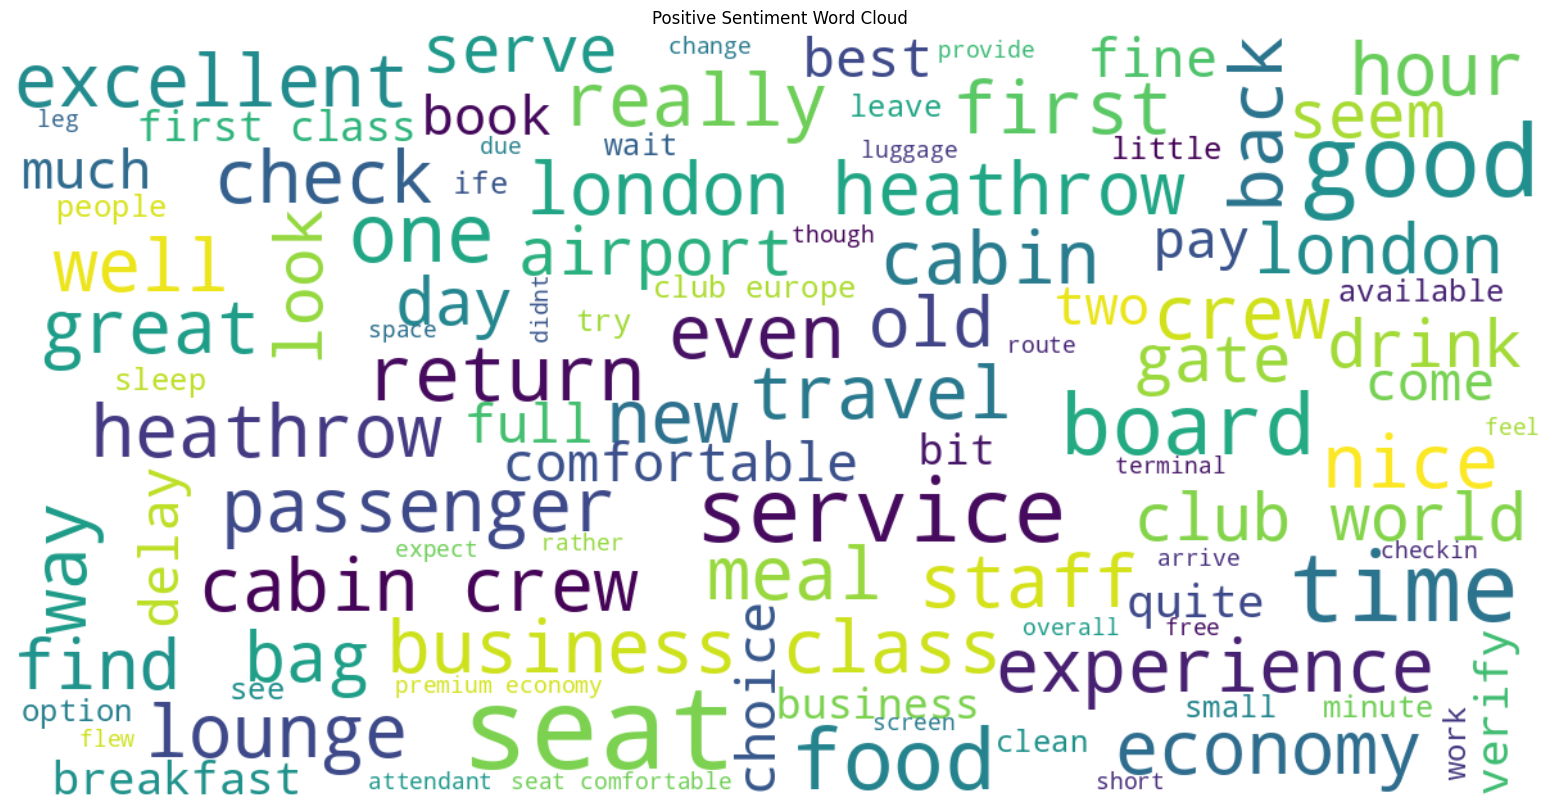

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wordcloud = WordCloud(
        background_color='white',
        max_words=100,
        max_font_size=30,
        scale=3,
        random_state=1)

lemmatized_reviews = ' '.join(df[df['sentiment_textblob']=='positive']['final_reviews'])
wordcloud=wordcloud.generate(lemmatized_reviews)

plt.figure(figsize=(20, 10))
plt.axis('off')
plt.title("Positive Sentiment Word Cloud")
plt.imshow(wordcloud, interpolation='bilinear')
plt.show()

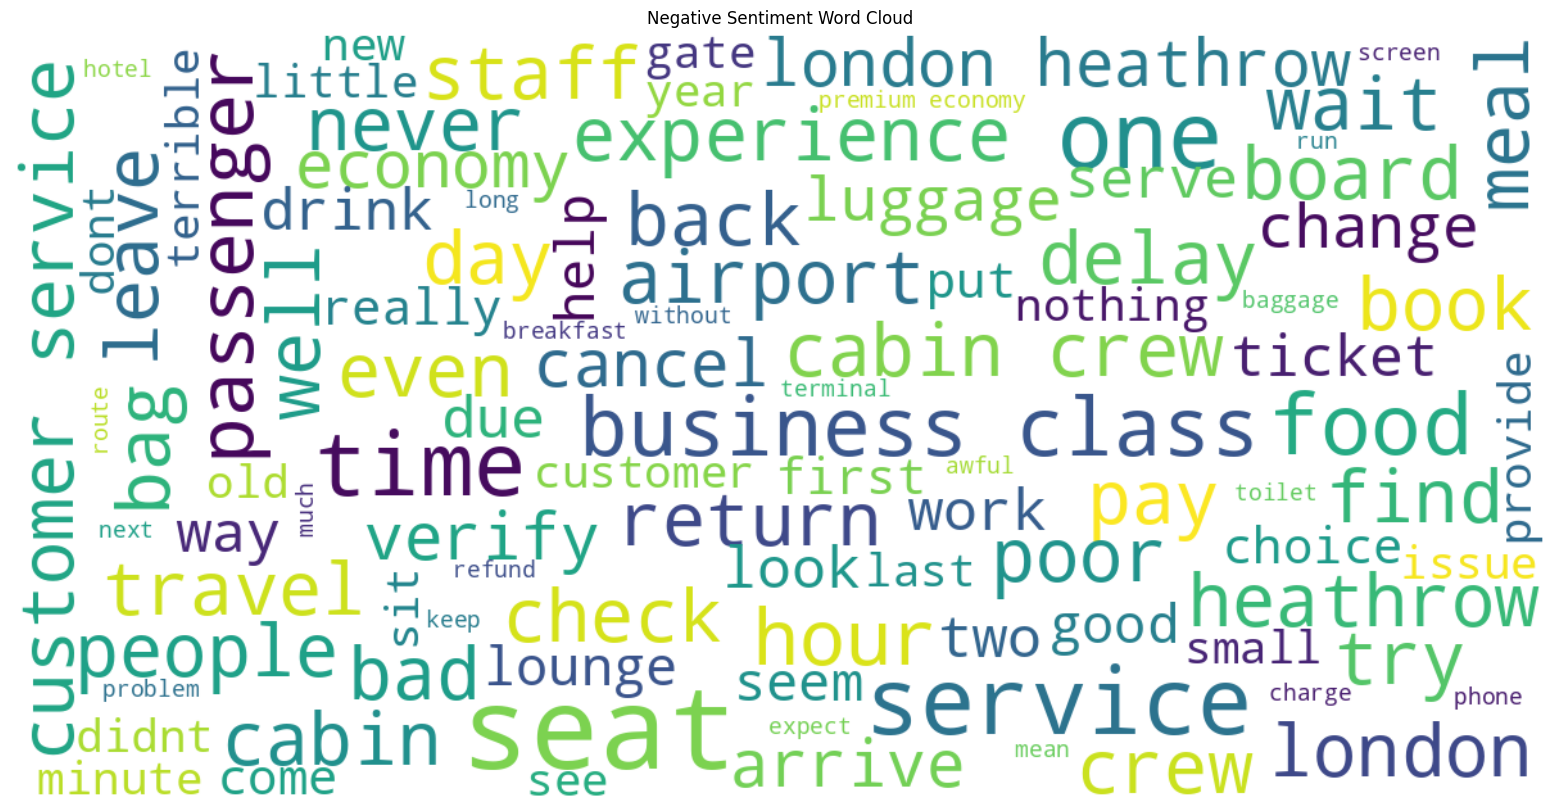

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wordcloud = WordCloud(
        background_color='white',
        max_words=100,
        max_font_size=30,
        scale=3,
        random_state=1)

lemmatized_reviews = ' '.join(df[df['sentiment_textblob']=='negative']['final_reviews'])
wordcloud=wordcloud.generate(lemmatized_reviews)

plt.figure(figsize=(20, 10))
plt.axis('off')
plt.title("Negative Sentiment Word Cloud")
plt.imshow(wordcloud, interpolation='bilinear')
plt.show()